# Data Preprocessing


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/Final_merged_reduced_intents_cleaned_153k_v15.csv")
df.head()

,instructions,intents
0,what do i need to do to change to the gold acc...,account_management
1,i try to modify the shippig address,account_management
2,how cani change order {{order number}}?,order_management
3,how could i enter afucking delivery address,account_management
4,can uhelp me canceling order {{order number}},order_management


In [ ]:
for i,intents in enumerate(df['intents'].unique(),start=1):
  print(i,".",intents)

1 . account_management
2 . order_management
3 . billing_and_payment
4 . issue_support
5 . customer_care_support
6 . place_order
7 . order_tracking
8 . delivery_options
9 . submit_feedback
10 . product_inquiry
11 . add_to_cart
12 . remove_from_cart
13 . store_information
14 . shipping_cost
15 . out_of_scope


In [ ]:
df.shape

(153460, 2)

In [ ]:
(153460, 2)

In [ ]:
import pandas as pd

intent_counts = df['intents'].value_counts()
print("Intents with the least instructions (top 10):")
print(intent_counts.head(20))

Intents with the least instructions (top 10):
intents
issue_support            27797
order_tracking           17266
account_management       17082
product_inquiry          16150
order_management          9775
out_of_scope              9020
billing_and_payment       8949
place_order               8305
submit_feedback           6120
delivery_options          5816
customer_care_support     5668
remove_from_cart          5468
store_information         5438
shipping_cost             5383
add_to_cart               5223
Name: count, dtype: int64


### Distribution of Intents

Let's visualize the distribution of the `intents` column to see the frequency of each class. This is important for understanding potential class imbalance issues.

/tmp/ipykernel_160/3108366496.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='intents', data=df, order=df['intents'].value_counts().index, palette='viridis')


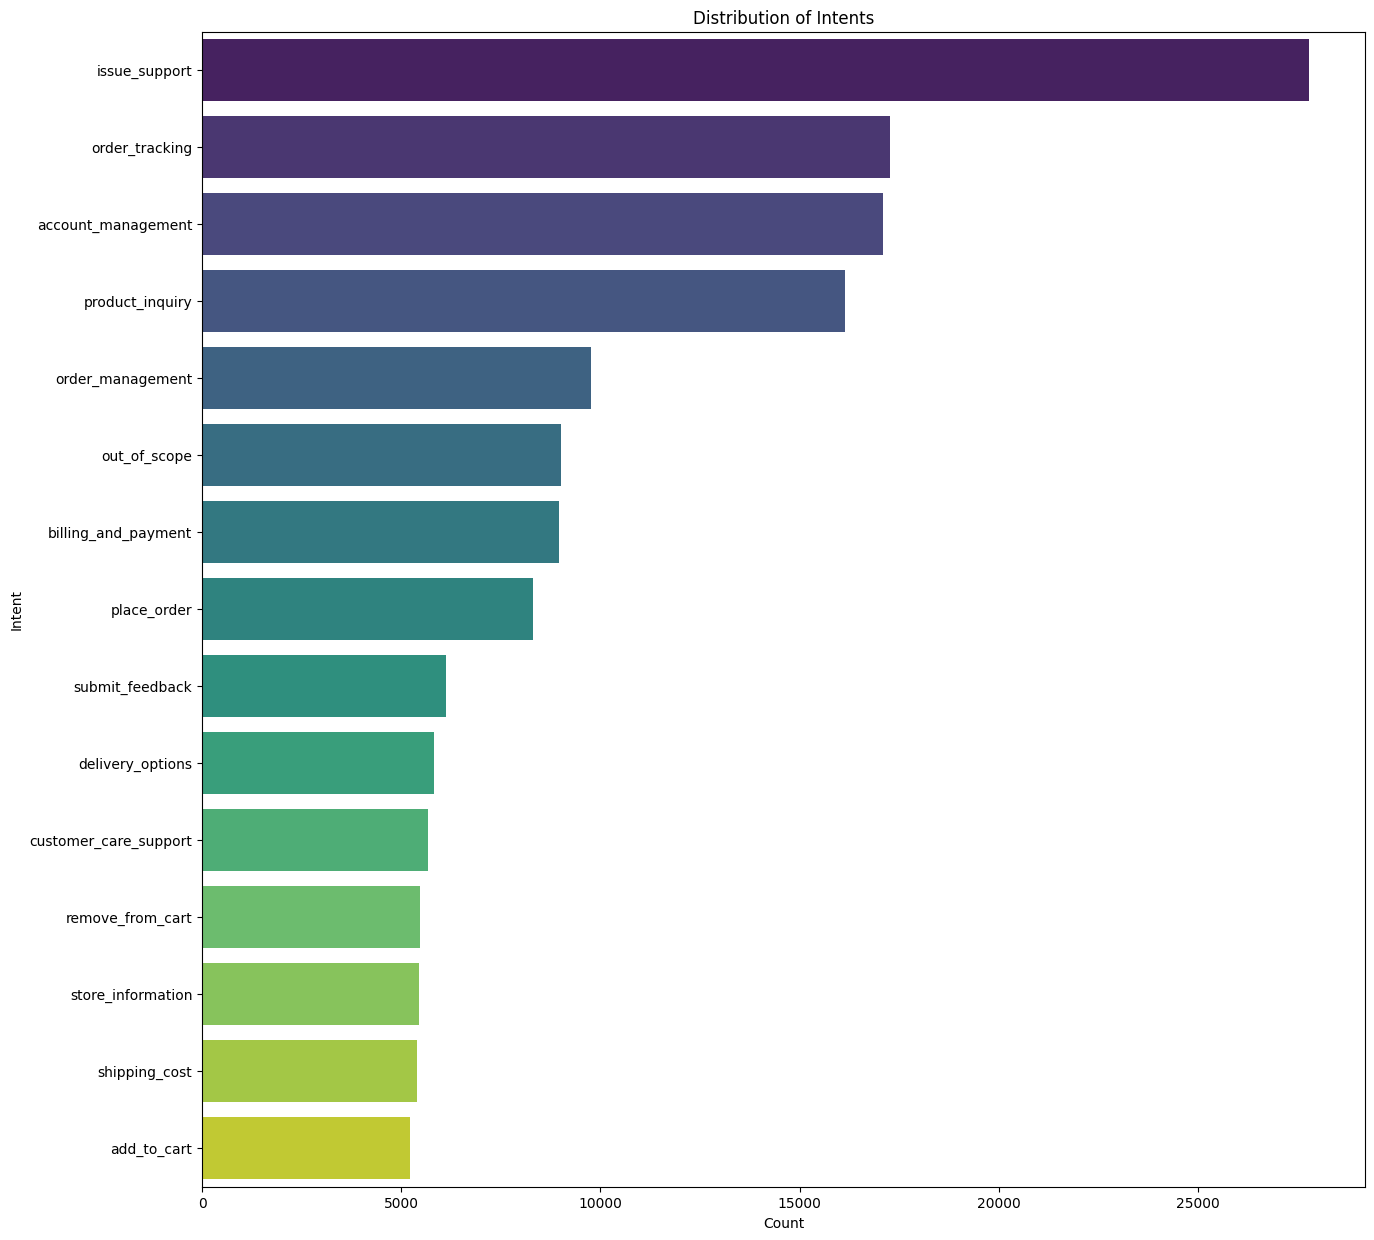

In [ ]:
plt.figure(figsize=(15, 15))
sns.countplot(y='intents', data=df, order=df['intents'].value_counts().index, palette='viridis')
plt.title('Distribution of Intents')
plt.xlabel('Count')
plt.ylabel('Intent')
plt.show()

In [ ]:
df['intents'].unique()

array(['switch_account', 'set_up_address', 'change_order', 'cancel_order',
       'get_invoice', 'refund_request', 'recover_password',
       'delete_account', 'customer_care_support', 'place_order',
       'registration_problems', 'delivery_time', 'create_account',
       'check_cancellation_fee', 'edit_account', 'payment_options',
       'track_order', 'delivery_options', 'payment_issue',
       'submit_feedback', 'product_search', 'add_to_cart',
       'item_availability', 'product_issue', 'delivery_issue',
       'product_exchange', 'missing_item', 'order_history',
       'product_information', 'remove_from_cart', 'product_return',
       'sales_period', 'shipping_cost', 'store_location',
       'store_opening_hours', 'wrong_item', 'out_of_scope'], dtype=object)

In [ ]:
df['intents'].nunique()

37

In [ ]:
import pandas as pd

# Step 1: Load your CSV file
df = pd.read_csv("/content/merged_cleaned_100k_v11.csv")  # replace with your CSV file path

In [ ]:
# Specify the intent
target_intent = "remove_from_cart"

# Filter instructions for that intent
instructions_only = df[df['intents'] == target_intent]['instructions']

# Optional: Convert to a list
instructions_list = instructions_only.tolist()

# Print the instructions
for i, instr in enumerate(instructions_list, 1):
    print(f"{i}. {instr}")

1. i need help to remove fucking products from the basket
2. i got to remove a product from the baskte
3. need to remove products from the basket how to do it
4. i have to remove a fucking product from the catr, how could i do it?
5. i'd like to remove fucking items from the basket, how to do it?
6. i'd like to remove an item from the cart, where could i do it?
7. can ya help me to remove a product from the cart
8. help me removing a fucking productfrom the basket
9. need to remove products from the cart how could i do it
10. i got to remove an item from the car, how can i do it?
11. how could i remove an item from the basket ?
12. i need assistance removing fucking items from the basket
13. i'd like to remove a fucking product from the basket will uhelp me
14. i got to remove a fucking product from the cart help me
15. could i remove fucking items from the basket
16. need to remove a fucking item from the cart how could i do it
17. i need to remove a product frrom the cart, how can i 

In [ ]:
# Remove rows with the "change_order" intent
df_filtered = df[df['intents'] != "change_order"]

# Save the updated dataset to a new CSV (or overwrite the existing one)
df_filtered.to_csv("dataset_without_change_order_v10.csv", index=False)

print("change_order intent has been removed. Updated dataset saved!")

change_order intent has been removed. Updated dataset saved!


In [ ]:
print(df_filtered.shape)
print(df_filtered['intents'].nunique())

(79661, 2)
36


#Model Training

In [ ]:
!pip install transformers datasets scikit-learn pandas torch

In [ ]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
import random

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score

from datasets import Dataset
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

# =========================
# 2. SET SEED
# =========================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# =========================
# 3. LOAD DATASET
# =========================
df = pd.read_csv("/content/Final_merged_reduced_intents_cleaned_153k_v15.csv")

# =========================
# 4. CLEANING
# =========================
df = df.dropna(subset=["instructions", "intents"])
df = df[df["instructions"].str.strip() != ""]
df = df.drop_duplicates()
df["instructions"] = df["instructions"].str.strip()

print("Dataset size:", len(df))

# =========================
# 5. LABEL ENCODING
# =========================
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["intents"])
num_labels = len(label_encoder.classes_)

print("Number of classes:", num_labels)

# =========================
# 6. TRAIN / VAL / TEST SPLIT (70/15/15)
# =========================
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

# =========================
# 7. CONVERT TO HF DATASET
# =========================
train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
val_dataset = Dataset.from_pandas(val_df.reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_df.reset_index(drop=True))

# Remove unused columns
columns_to_remove = [col for col in train_dataset.column_names if col not in ["instructions", "label"]]
train_dataset = train_dataset.remove_columns(columns_to_remove)
val_dataset = val_dataset.remove_columns(columns_to_remove)
test_dataset = test_dataset.remove_columns(columns_to_remove)

# =========================
# 8. TOKENIZER
# =========================
tokenizer = DistilBertTokenizerFast.from_pretrained(
    "distilbert-base-uncased"
)

def tokenize(batch):
    return tokenizer(
        batch["instructions"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
val_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])

# =========================
# 9. LOAD MODEL
# =========================
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_labels
)

id2label = {i: label for i, label in enumerate(label_encoder.classes_)}
label2id = {label: i for i, label in enumerate(label_encoder.classes_)}

model.config.id2label = id2label
model.config.label2id = label2id

# =========================
# 10. METRICS (TOP-1 + TOP-2)
# =========================
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    # Convert logits → softmax probabilities
    probs = torch.tensor(logits)
    probs = F.softmax(probs, dim=1)

    # Top-1 predictions
    top1_preds = torch.argmax(probs, dim=1).numpy()

    # Top-2 predictions
    top2_preds = torch.topk(probs, k=2, dim=1).indices.numpy()

    # Top-1 Accuracy
    top1_accuracy = accuracy_score(labels, top1_preds)

    # Top-2 Accuracy
    top2_correct = sum(
        label in top2
        for label, top2 in zip(labels, top2_preds)
    )
    top2_accuracy = top2_correct / len(labels)

    # F1 (Top-1 based)
    f1_weighted = f1_score(labels, top1_preds, average="weighted")

    return {
        "top1_accuracy": top1_accuracy,
        "top2_accuracy": top2_accuracy,
        "f1_weighted": f1_weighted
    }

# =========================
# 11. TRAINING ARGUMENTS
# =========================
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    greater_is_better=True,
    num_train_epochs=8,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    weight_decay=0.01,
    logging_dir="./logs",
    save_total_limit=2,
    fp16=torch.cuda.is_available(),
    seed=42
)

# =========================
# 12. TRAINER
# =========================
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

# =========================
# 13. TRAIN
# =========================
trainer.train()

# =========================
# 14. FINAL TEST EVALUATION
# =========================
print("\nFinal Test Evaluation:")
test_results = trainer.evaluate(test_dataset)
print(test_results)


Dataset size: 153464
Number of classes: 15
Train: 107424
Validation: 23020
Test: 23020


Map:   0%|          | 0/107424 [00:00<?, ? examples/s]

Map:   0%|          | 0/23020 [00:00<?, ? examples/s]

Map:   0%|          | 0/23020 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



Final Test Evaluation:


{'eval_loss': 0.0550968274474144, 'eval_top1_accuracy': 0.993136403127715, 'eval_top2_accuracy': 0.9982189400521286, 'eval_f1_weighted': 0.9931369941362048, 'eval_runtime': 23.0484, 'eval_samples_per_second': 998.769, 'eval_steps_per_second': 62.434, 'epoch': 8.0}


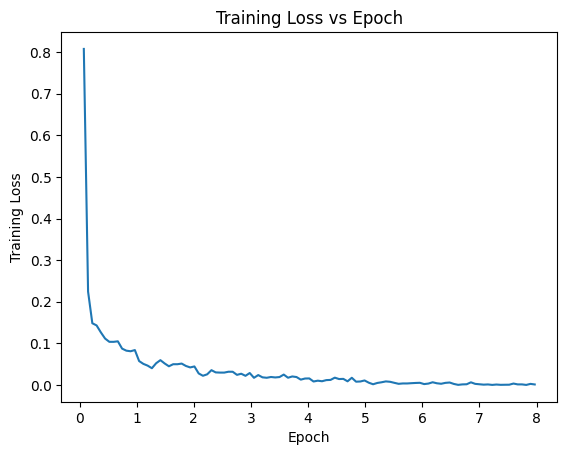

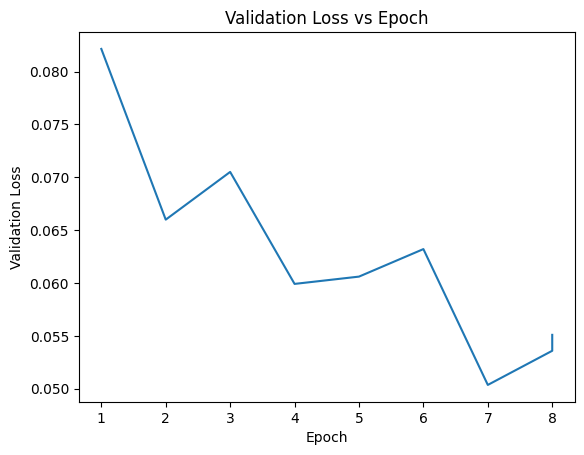

In [ ]:
## Training and validation Loss graph

import matplotlib.pyplot as plt
import pandas as pd

# Convert log history to DataFrame
logs = pd.DataFrame(trainer.state.log_history)

# Extract training and validation logs
train_logs = logs[logs["loss"].notna()]
eval_logs = logs[logs["eval_loss"].notna()]

# Plot Training Loss
plt.figure()
plt.plot(train_logs["epoch"], train_logs["loss"])
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epoch")
plt.show()

# Plot Validation Loss
plt.figure()
plt.plot(eval_logs["epoch"], eval_logs["eval_loss"])
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss vs Epoch")
plt.show()


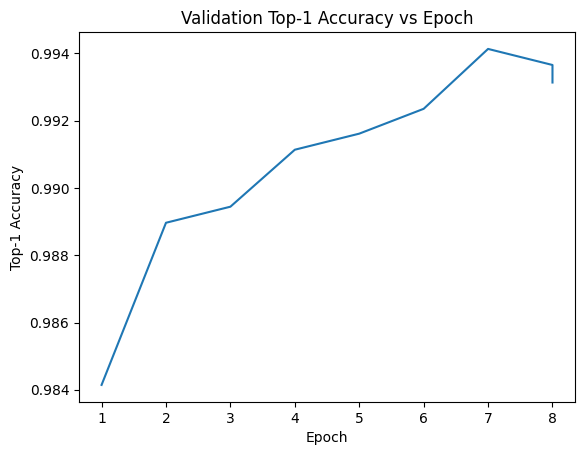

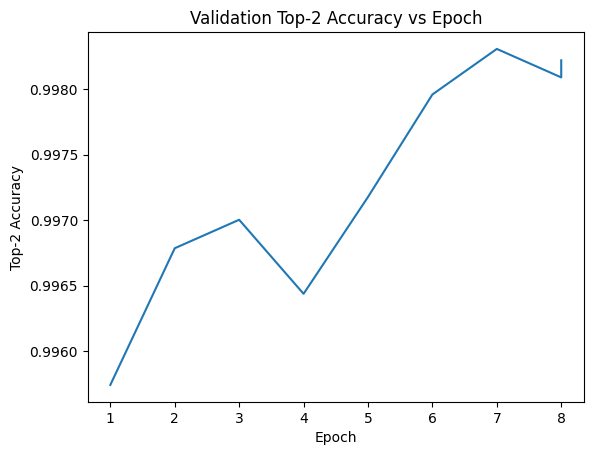

In [ ]:
# Plot Top-1 Accuracy
plt.figure()
plt.plot(eval_logs["epoch"], eval_logs["eval_top1_accuracy"])
plt.xlabel("Epoch")
plt.ylabel("Top-1 Accuracy")
plt.title("Validation Top-1 Accuracy vs Epoch")
plt.show()

# Plot Top-2 Accuracy
plt.figure()
plt.plot(eval_logs["epoch"], eval_logs["eval_top2_accuracy"])
plt.xlabel("Epoch")
plt.ylabel("Top-2 Accuracy")
plt.title("Validation Top-2 Accuracy vs Epoch")
plt.show()


In [ ]:
# Save final trained model
trainer.save_model("final_production_model")

# Save tokenizer
tokenizer.save_pretrained("final_production_model")

print("Model saved successfully ✅")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved successfully ✅


In [ ]:
# Shows model's total size
import os

def folder_size(path="."):
    total = 0
    for dirpath, dirnames, filenames in os.walk(path):
        for f in filenames:
            fp = os.path.join(dirpath, f)
            total += os.path.getsize(fp)
    return total

size_bytes = folder_size("final_production_model")
print(f"Model size on disk: {size_bytes/1e6:.2f} MB")

Model size on disk: 268.59 MB


In [ ]:
# Shows model's total parameters
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained("final_production_model")

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params/1e6:.2f} M")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Total parameters: 66.97 M


In [ ]:
## Manual Prediction Function

import torch
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

model.eval()

def predict_intent(text, top_k=2):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    # Move inputs to same device as model
    inputs = {key: value.to(device) for key, value in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits

        probs = F.softmax(logits, dim=1)
        topk_probs, topk_indices = torch.topk(probs, k=top_k, dim=1)

    topk_probs = topk_probs[0].cpu().numpy()
    topk_indices = topk_indices[0].cpu().numpy()

    intents = label_encoder.inverse_transform(topk_indices)

    return list(zip(intents, topk_probs))


print(predict_intent("I  wsnto get the realme c34"))


In [ ]:
# Save model in local system

import shutil
from google.colab import files

# 1️⃣ Zip the folder
shutil.make_archive("/content/final_production_model", 'zip', "/content/final_production_model")

# 2️⃣ Download the zip
files.download("/content/final_production_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip freeze > requirements.txt